In [1]:
import torch
import os
from utilities import *
device = torch.device('cpu')

c:\Users\runan\kan-robustness-scaling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
dim = 100
data = 'C'
seeds = [0]  
noise_levels = [0, 0.02, 0.04, 0.1, 0.2] 
n_train = 1000
n_test = 1000
steps = 200
grids = [3, 5, 10, 20, 50, 100]
lr = 1.0
k = 3

In [104]:
def train_kan_on_noise(seed, noise, dim, data):
    dataset = torch.load(os.path.join('datasets', f'seed {seed}', f'{data}_dataset_dim{dim}_seed{seed}.pt'), map_location='cpu')
    sigma = float(noise * torch.std(dataset['test_label']))
    dataset['train_input'] = dataset['train_input'] + sigma * torch.randn_like(dataset['train_input'])
    dataset['test_input'] = dataset['test_input'] + sigma * torch.randn_like(dataset['test_input'])
    dataset['train_label'] = dataset['train_label'] + sigma * torch.randn_like(dataset['train_label'])
    dataset['test_label'] = dataset['test_label'] + sigma * torch.randn_like(dataset['test_label'])

    width = [dim, 1, 1]

    result = {}
    print(f'\nSeed {seed} | noise={sigma}: running static KAN')
    result['static'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=True, k=k, device=device)

    print(f'Seed {seed} | noise={sigma}: running dynamic KAN')
    result['dynamic'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=False, k=k, device=device)

    print(f'Seed {seed} | noise={sigma}: running MLP')
    mlp_hidden_width = math.ceil((10*dim+11)/(dim+2)) - 1
    result['mlp'] = train_mlp(width=[dim, mlp_hidden_width, 1], dataset=dataset, steps=steps, lr=lr, seed=seed)

    
    dir = os.path.join('4-results-noise-new', f'seed-{seed}')
    os.makedirs(dir, exist_ok=True)
    torch.save(result, os.path.join(dir, f'{data}_dim{dim}_noise_{sigma:.3f}.pt'))
    return result


In [ ]:
results = {}
for seed in seeds:
    for noise in noise_levels:
        results[(seed, noise)] = train_kan_on_noise(seed, noise)

In [121]:
def plot(results, seeds, data, dim):

    noise_values = sorted(results[seeds[0]].keys())
    static_rmse = [results[seeds[0]][noise]['static']['rmses'][-1] for noise in noise_values]
    dynamic_rmse = [results[seeds[0]][noise]['dynamic']['rmses'][-1] for noise in noise_values]
    mlp_rmse = [results[seeds[0]][noise]['mlp']['test_loss'][-1] if 'test_loss' in results[seeds[0]][noise]['mlp'] else results[seeds[0]][noise]['mlp'].get('rmses', [None])[-1] for noise in noise_values]

    static_r2 = [results[seeds[0]][noise]['static']['r2s'][-1] for noise in noise_values]
    dynamic_r2 = [results[seeds[0]][noise]['dynamic']['r2s'][-1] for noise in noise_values]
    mlp_r2 = [results[seeds[0]][noise]['mlp']['r2s'][-1] if 'r2s' in results[seeds[0]][noise]['mlp'] else None for noise in noise_values]

    # fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # axes[0].plot(noise_values, static_rmse, marker='s', label='Static KAN')
    # axes[0].plot(noise_values, dynamic_rmse, marker='^', label='Dynamic KAN')
    # axes[0].plot(noise_values, mlp_rmse, marker='o', label='MLP')
    # axes[0].set_xlabel('Noise $\sigma$')
    # axes[0].set_ylabel('RMSE')
    # axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))

    # axes[0].yaxis.set_major_locator(plt.MaxNLocator(nbins=5))

    # axes[1].plot(noise_values, static_r2, marker='s')
    # axes[1].plot(noise_values, dynamic_r2, marker='^')
    # if any(v is not None for v in mlp_r2):
    #     axes[1].plot(noise_values, mlp_r2, marker='o')
    # axes[1].set_xlabel('Noise $\sigma$')
    # axes[1].set_ylabel('R2')
    # axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
    # fig.legend()

    fig, ax = plt.subplots(figsize=(5, 5))

    # Plot lines
    ax.plot(noise_values, static_r2, marker='s', label='Static KAN')
    ax.plot(noise_values, dynamic_r2, marker='^', label='Dynamic KAN')
    if any(v is not None for v in mlp_r2):
        ax.plot(noise_values, mlp_r2, marker='o', label='MLP')
        
    # Formatting
    ax.set_xlabel('Noise $\sigma$')
    ax.set_ylabel('$R^2$')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

    fig.suptitle(f'Noise sensitivity, data {data}, dim {dim}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    fig.savefig(f'noise_sensitivity_{data}_dim{dim}.png', 
                bbox_inches='tight', dpi=300)


<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
C:\Users\runan\AppData\Local\Temp\ipykernel_55672\2138802854.py:41: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('Noise $\sigma$')


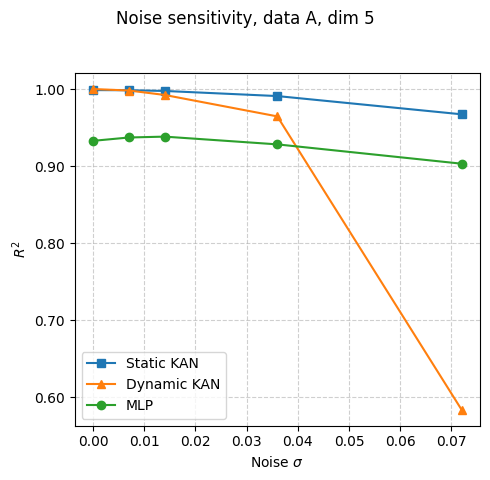

In [124]:
plot(A_dim5, seeds, 'A', 5)

In [108]:
for seed in seeds:
    for noise in noise_levels:
        results[(seed, noise)] = train_kan_on_noise(seed, noise, 5, 'C')


Seed 0 | noise=0.0: running static KAN


Seed 0 | noise=0.0: running dynamic KAN


Seed 0 | noise=0.0: running MLP


| train_loss: 7.24e-05 | test_loss: 7.42e-05 | reg: 2.56e+01 | : 100%|█| 200/200 [00:07<00:00, 27.15



Seed 0 | noise=0.005795084871351719: running static KAN


...

Seed 0 | noise=0.11590170115232468: running MLP


| train_loss: 1.38e-01 | test_loss: 1.77e-01 | reg: 6.99e+01 | : 100%|█| 200/200 [00:13<00:00, 14.31



Seed 0 | noise=0.2897542417049408: running static KAN


Seed 0 | noise=0.2897542417049408: running dynamic KAN


ValueError: Input contains NaN.

In [ ]:
for seed in seeds:
    for noise in noise_levels:
        results[(seed, noise)] = train_kan_on_noise(seed, noise, 5, 'A')

In [ ]:
for seed in seeds:
    for noise in noise_levels:
        results[(seed, noise)] = train_kan_on_noise(seed, noise, 100, 'C')

In [40]:
print(results.keys())

dict_keys([(0, 0.01), (0, 0.02), (0, 0.05), (0, 0.1), (0, 0.2), (0, 0), (0, 0.04)])


In [109]:
import os
import glob
import torch

def load_kan_results(data_name,  dim):

    compiled_results = {}
    
    search_pattern = os.path.join('4-results-noise', 'seed-*', f'{data_name}_dim{dim}_noise_*.pt')
    matching_files = glob.glob(search_pattern)
    
    if not matching_files:
        print('No files found for equation')
        return compiled_results

    for file_path in matching_files:
        path_parts = file_path.split(os.sep)
        seed_str = [part for part in path_parts if part.startswith('seed-')][0]
        seed = int(seed_str.split('-')[1])
        filename = os.path.basename(file_path)
        try:
            sigma_str = filename.split('_noise_')[1].replace('.pt', '')
            sigma = float(sigma_str)
        except (IndexError, ValueError):
            sigma = filename # Fallback to string if naming structure differs
            
        # Load the PyTorch file
        result_data = torch.load(file_path, map_location='cpu', weights_only=False)
        
        # Organize into the compiled dictionary
        if seed not in compiled_results:
            compiled_results[seed] = {}
            
        compiled_results[seed][sigma] = result_data

    print(f"Successfully loaded {len(matching_files)} result file(s).")
    return compiled_results

In [110]:
# C_dim100 = load_kan_results('C', 100)
C_dim5 = load_kan_results('C', 5)
B_dim5 = load_kan_results('B', 5)
A_dim5 = load_kan_results('A', 5)

Successfully loaded 5 result file(s).
Successfully loaded 5 result file(s).
Successfully loaded 5 result file(s).


In [57]:
print(C_dim5[0].keys())

dict_keys([0.0, 0.012, 0.023, 0.058, 0.116])


In [ ]:
def train_kan_on_outliers(seed, outlier_pct, dim, data):
    """Train KAN/MLP with a percentage of labels replaced by 1000% of max value (outlier injection)."""
    dataset = torch.load(os.path.join('datasets', f'seed {seed}', f'{data}_dataset_dim{dim}_seed{seed}.pt'), map_location='cpu')
    
    # Clone to avoid modifying original
    dataset = {k: v.clone() for k, v in dataset.items()}
    
    outlier_pct_float = float(outlier_pct)
    max_val = torch.max(torch.abs(dataset['test_label'])).item()
    outlier_val = 10.0 * max_val 
    
    # Inject outliers into train labels
    n_train_outliers = int(np.ceil(dataset['train_label'].shape[0] * outlier_pct_float / 100.0))
    if n_train_outliers > 0:
        train_indices = np.random.choice(dataset['train_label'].shape[0], n_train_outliers, replace=False)
        dataset['train_label'][train_indices] = outlier_val
    
    # Inject outliers into test labels
    n_test_outliers = int(np.ceil(dataset['test_label'].shape[0] * outlier_pct_float / 100.0))
    if n_test_outliers > 0:
        test_indices = np.random.choice(dataset['test_label'].shape[0], n_test_outliers, replace=False)
        dataset['test_label'][test_indices] = outlier_val
    
    width = [dim, 1, 1]
    
    result = {}
    print(f'\nSeed {seed} | outlier%={outlier_pct_float}: running static KAN')
    result['static'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=True, k=k, device=device)
    
    print(f'Seed {seed} | outlier%={outlier_pct_float}: running dynamic KAN')
    result['dynamic'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=False, k=k, device=device)
    
    print(f'Seed {seed} | outlier%={outlier_pct_float}: running MLP')
    mlp_hidden_width = math.ceil((10*dim+11)/(dim+2)) - 1
    result['mlp'] = train_mlp(width=[dim, mlp_hidden_width, 1], dataset=dataset, steps=steps, lr=lr, seed=seed)
    
    dir = os.path.join('4-results-noise-extreme', f'seed-{seed}')
    os.makedirs(dir, exist_ok=True)
    torch.save(result, os.path.join(dir, f'{data}_dim{dim}_outlier_{outlier_pct_float:.1f}pct.pt'))
    return result


In [98]:
outlier_pcts = [0, 0.5, 1, 2, 5]

for seed in seeds:
    for outlier_pct in outlier_pcts:
        train_kan_on_outliers(seed, outlier_pct, 5, 'A')



Seed 0 | outlier%=0.0: running static KAN


Grid=3:   0%|          | 0/200 [00:00<?, ?it/s]

Seed 0 | outlier%=0.0: running dynamic KAN


Seed 0 | outlier%=0.0: running MLP


| train_loss: 7.93e-02 | test_loss: 9.28e-02 | reg: 5.75e+01 | : 100%|█| 200/200 [00:19<00:00, 10.24


...

| train_loss: 3.21e+00 | test_loss: 3.94e+00 | reg: 1.00e+03 | : 100%|█| 200/200 [00:08<00:00, 24.68



Seed 0 | outlier%=5.0: running static KAN


Seed 0 | outlier%=5.0: running dynamic KAN


Seed 0 | outlier%=5.0: running MLP


| train_loss: 5.43e+00 | test_loss: 5.68e+00 | reg: 2.31e+02 | : 100%|█| 200/200 [00:12<00:00, 15.76


In [ ]:
for seed in seeds:
    for outlier_pct in outlier_pcts:
        train_kan_on_outliers(seed, outlier_pct, 5, 'B')

In [99]:
for seed in seeds:
    for outlier_pct in outlier_pcts:
        train_kan_on_outliers(seed, outlier_pct, 5, 'C')


Seed 0 | outlier%=0.0: running static KAN


Seed 0 | outlier%=0.0: running dynamic KAN


Seed 0 | outlier%=0.0: running MLP


| train_loss: 7.24e-05 | test_loss: 7.42e-05 | reg: 2.56e+01 | : 100%|█| 200/200 [00:07<00:00, 26.49



Seed 0 | outlier%=0.5: running static KAN


...

| train_loss: 2.79e+00 | test_loss: 2.96e+00 | reg: 3.38e+02 | : 100%|█| 200/200 [00:20<00:00,  9.88



Seed 0 | outlier%=5.0: running static KAN


Seed 0 | outlier%=5.0: running dynamic KAN


Seed 0 | outlier%=5.0: running MLP


| train_loss: 4.23e+00 | test_loss: 4.77e+00 | reg: 6.27e+02 | : 100%|█| 200/200 [00:25<00:00,  7.71


In [100]:
for seed in seeds:
    for outlier_pct in outlier_pcts:
        train_kan_on_outliers(seed, outlier_pct, 100, 'C')


Seed 0 | outlier%=0.0: running static KAN


Seed 0 | outlier%=0.0: running dynamic KAN


Seed 0 | outlier%=0.0: running MLP


| train_loss: 7.67e-05 | test_loss: 5.24e-04 | reg: 1.02e+02 | : 100%|█| 200/200 [00:20<00:00,  9.70



Seed 0 | outlier%=0.5: running static KAN


...

| train_loss: 3.40e-03 | test_loss: 4.51e+00 | reg: 4.93e+02 | : 100%|█| 200/200 [00:18<00:00, 10.64



Seed 0 | outlier%=5.0: running static KAN


Seed 0 | outlier%=5.0: running dynamic KAN


Seed 0 | outlier%=5.0: running MLP


| train_loss: 1.29e-02 | test_loss: 8.69e+00 | reg: 9.08e+02 | : 100%|█| 200/200 [00:19<00:00, 10.01
